In [14]:
import os
import cv2 
from random import shuffle
import numpy as np
from tqdm import tqdm
import datashader as ds
from matplotlib import pyplot as plt

In [3]:
def load_data(test_pc=0.3, img_size=256):
    data = []
    images_directory = "routes-generated/final"

    # image file names are as follows: day-##-hour-##.png
        # ex. day-12-hour-3.png
        # image for the 12th day at 3am
        # label is 3, day is ignored

    # going through images in folder
    for image_name in tqdm(os.listdir(images_directory)):
        # image path
        image_path = os.path.join(images_directory, image_name)
        
        # get label (hour) from file name
        label = image_name.split('-')[3].split('.')[0]

        # resizing each image to 256x256
        image = cv2.resize(cv2.imread(image_path), (img_size, img_size))
        
        # OpenCV defaults to BGR by default, changing to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # appending image along with label to list
        data.append([np.array(image), np.array(np.uint8(label))])
    
    # shuffling images
    shuffle(data)

    # get all images into separate list
    images = [pair[0] for pair in data]
    # get all labels into separate list
    labels = [pair[1] for pair in data]

    # gets index at which test_pc (say 0.3) happens, takes ceiling to avoid decimal index and casts to int
    test_index_split = int(np.ceil(len(data)*test_pc))

    # split test and train
    # note: already shuffled so ok to slice as beginning:end
    trainX = images[test_index_split:]
    trainy = labels[test_index_split:]
    testX = images[:test_index_split]
    testy = labels[:test_index_split]

    # return as (trainX, trainy), (testX, testy) tuple 
    return (np.array(trainX), np.array(trainy)), (np.array(testX), np.array(testy))

In [216]:
(trainX, trainy), (testX, testy) = load_data()

100%|██████████| 588/588 [00:04<00:00, 142.00it/s]


In [231]:
image.shape

(500, 500, 3)

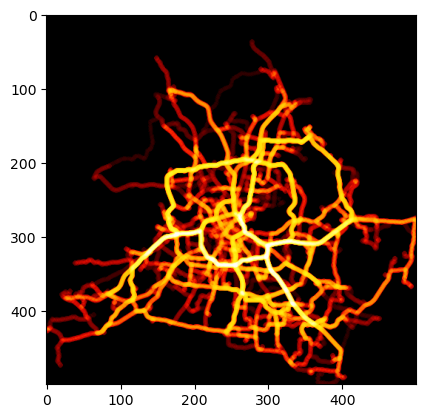

In [230]:
image = cv2.imread("routes-generated/test-prep/day-1-hour-10.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [ ]:
(trainX, trainy), (testX, testy) = load_data(img_size=128)
plt.imshow(trainX[3])

100%|██████████| 588/588 [00:03<00:00, 175.94it/s]


In [25]:
def save_as_size(img_size):
    print("Loading 500x500 from local directory...")
    (trainX, _), (testX, _) = load_data(img_size=img_size)
    bothX = [trainX, testX]
    i = 0
    print("Converting images to {a}x{a}...".format(a=img_size))
    for set in bothX:
        for image in tqdm(set):
            plt.imsave('routes-generated/maps-{}/train{}-{}.png'.format(img_size, i, img_size), image)
            i = i + 1
        

In [28]:
save_as_size(img_size=256)

Loading 500x500 from local directory...


100%|██████████| 588/588 [00:03<00:00, 155.77it/s]


Converting images to 256x256...


100%|██████████| 177/177 [00:03<00:00, 52.78it/s]
